In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

from armored.models import *
from armored.preprocessing import *

import itertools
from tqdm import tqdm

import shap

params = {
    'figure.figsize': (3, 4),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

/home/jaron/.venvs/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# data with initial and end point measurements
df_exp0 = pd.read_csv("data/exp0/exp0_metabolites.csv")
df_exp1 = pd.read_csv("data/exp1/exp1_metabolites.csv")
df_exp2 = pd.read_csv("data/exp2/exp2_metabolites.csv")
df_exp3 = pd.read_csv("data/exp3/exp3_metabolites.csv")
df_exp4a = pd.read_csv("data/exp4/exp4_metabolites_best_reps.csv")
df_exp4b = pd.read_csv("data/exp4/exp4_metabolites_new_best.csv")
df_exp4c = pd.read_csv("data/exp4/exp4_metabolites_new_worst.csv")
df = pd.concat((df_exp0, df_exp1, df_exp2, df_exp3, df_exp4a, df_exp4b, df_exp4c))

# define variable names
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))
system_variables

# average replicates
df_fmt_mean = []
for exp_name, df_exp in df.groupby("Experiments"):
    df_groups = df_exp.groupby("Time")
    df_avg = df_groups[system_variables].mean().reset_index()
    df_avg.insert(0, "Experiments", [exp_name]*df_avg.shape[0])
    df_fmt_mean.append(df_avg)
df = pd.concat(df_fmt_mean)

In [3]:
# log that ignores zeros
def zlog(x):
    x[x <= 0] = 1
    return np.log(x)

# shannon diversity
def shannon(y):
    y_rel = y / np.sum(y)
    return np.nansum(-zlog(y_rel)*y_rel)

# define objective 
def objective(y):
    # y is measured exp data [n_time, n_species + n_metabolites]
    
    # endpoint shannon diversity
    diversity = shannon(y[-1, :len(species)])
    
    # variance in species abundances in last two passages
    if np.any(np.isnan(y[-2:, :len(species)])):
        instability = np.nan
    else:
        species_stdv = np.std(y[-2:, :len(species)], 0)
        instability  = np.where(species_stdv>0, species_stdv, 0).mean() 
    
    # endpoint butyrate production 
    butyrate =  y[-1, -2]   
    
    return diversity, instability, butyrate

In [4]:
# determine names of experimental conditions 
all_treatments = df.Experiments.values
unique_treatments = np.unique(all_treatments) 

# scale data 
scaler = MinMaxScaler(observed, system_variables)
scaler.fit(df)
df_scaled = scaler.transform(df.copy())

# format data into matrix [n_samples, n_timepoints, dt+n_outputs+n_controls]
train_data = format_data(df, species, metabolites, controls, observed=observed)
train_data_scaled = format_data(df_scaled, species, metabolites, controls, observed=observed)

# instantiate model
brnn = miRNN(n_species=len(species), 
             n_metabolites=len(metabolites), 
             n_controls=len(controls), 
             n_hidden=32)

# fit model
brnn.fit(train_data_scaled, 
         alpha_0=0, alpha_1=1.,
         evd_tol=1e-3)

Total measurements: 27244, Number of parameters: 2515, Initial regularization: 0.00e+00
Loss: 1313.449, Residuals: -0.00282
Loss: 1255.873, Residuals: 0.00080
Loss: 1220.392, Residuals: 0.00080
Loss: 1072.720, Residuals: 0.00231
Loss: 1050.072, Residuals: -0.00241
Loss: 1046.116, Residuals: -0.00148
Loss: 924.369, Residuals: 0.00055
Loss: 865.425, Residuals: 0.00047
Loss: 845.115, Residuals: 0.00191
Loss: 759.131, Residuals: -0.00191
Loss: 751.453, Residuals: -0.00089
Loss: 738.825, Residuals: -0.00128
Loss: 715.509, Residuals: -0.00141
Loss: 713.209, Residuals: -0.00019
Loss: 663.841, Residuals: -0.00220
Loss: 656.739, Residuals: -0.00204
Loss: 649.132, Residuals: -0.00102
Loss: 634.077, Residuals: -0.00115
Loss: 609.677, Residuals: -0.00127
Loss: 604.251, Residuals: -0.00176
Loss: 560.813, Residuals: -0.00137
Loss: 557.911, Residuals: -0.00141
Loss: 555.806, Residuals: -0.00058
Loss: 536.393, Residuals: -0.00035
Loss: 508.130, Residuals: -0.00015
Loss: 506.380, Residuals: -0.00075
Lo

In [5]:
# create wrapper for brnn to match SHAP model 
def instability_model(X):
    
    # X is matrix of [n_samples, n_inputs] 
    # Decompose X into Species/Metabolites and Fibers
    Xsm = X[:, :len(observed)]
    Xf = X[:, len(observed):]
    
    # matrix of predictions over time
    Xf = np.stack([np.stack(4*[Xfi]) for Xfi in Xf])
    Y = nn.relu(brnn.forward_batch(brnn.params, Xsm, Xf))
    
    # standard deviation of species in last two passages
    Y_std = jnp.std(Y[:,-2:,:len(species)], 1)

    # replace zeros with NaN
    Y_std = Y_std.at[Y_std == 0].set(jnp.nan)
    
    # calculate instability as mean of standard deviation
    instability = jnp.nanmean(Y_std, 1)

    # return butyrate predictions
    return instability

In [6]:
# concatenate data points
Xs = []
all_exp_names = []

for (T, X, U, Y, exp_names) in train_data_scaled:
    
    all_exp_names.append(exp_names)
    for xi, ui in zip(X, U):
        
        # append design condition
        Xs.append(np.append(xi, ui[0]))
        
# stack 
X = np.stack(Xs)  
all_exp_names = np.concatenate(all_exp_names)

In [7]:
# init SHAP explainer with baseline
baseline = np.zeros([1, X.shape[-1]])
# baseline is zero for species, metabolites and fibers but pH is always normalized to 1
baseline[0,list(system_variables).index('pH')] = 1.

# SHAP explainer
feature_names = np.array([v.split("abs")[0] for v in system_variables])
instability_explainer = shap.Explainer(instability_model, baseline, feature_names=feature_names)

In [8]:
# explain conditions
instability_shap_values = instability_explainer(X)

PermutationExplainer explainer: 1186it [01:14, 15.76it/s]                       


In [9]:
instability_shap_features = []
for j, affecter in enumerate(system_variables):
    instability_shap_features.append(affecter+"-->Instability")

In [10]:
div = []
var = []
but = []
exp = []

# sort by exp names from training data 
for exp_name in all_exp_names:
    
    df_exp = df.iloc[df.Experiments.values==exp_name]
    
    div_val, var_val, but_val = objective(df_exp[species+metabolites].values)
    div.append(div_val)
    var.append(var_val)
    exp.append(exp_name)

    if df_exp.shape[0]>2:
        but.append(but_val)
    else:
        but.append(np.nan)
    
div = np.array(div)
var = np.array(var)
but = np.array(but)
exp = np.array(exp)

print("max diversity {:.3f}, max variation {:.5f}, max butyrate {:.3f}".format(np.max(div), np.nanmax(var), np.nanmax(but)))

max diversity 2.257, max variation 0.05319, max butyrate 24.206


In [11]:
df_sensitivity = pd.DataFrame()
df_sensitivity["Experiments"] = all_exp_names
df_sensitivity["Diversity"] = div
df_sensitivity["Instability"] = var
df_sensitivity["Butyrate"] = but

In [12]:
# add shap values
for i, shap_feature in enumerate(instability_shap_features):
    df_sensitivity[shap_feature] = instability_shap_values.values[:, i]

In [13]:
# add design conditions
for i, sys_var in enumerate(system_variables):
    if sys_var not in metabolites:
        df_sensitivity[sys_var] = X[:, i]

In [19]:
df_sensitivity

,Experiments,Diversity,Instability,Butyrate,ACabs-->Instability,BAabs-->Instability,BHabs-->Instability,BLabs-->Instability,BUabs-->Instability,CAabs-->Instability,...,FPabs,PCabs,PJabs,RIabs,AcGum,ArGal,Inulin,Pectin,Starch,Xylan
0,AC-AcGum,0.000000,0.000473,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.00000,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,AC-AcGum-ArGal-Inulin-Pectin-Starch,0.000000,0.003655,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.2,0.2,0.2,0.2,0.2,0.0
2,AC-AcGum-ArGal-Inulin-Pectin-Xylan,0.000000,0.004691,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.2,0.2,0.2,0.2,0.0,0.2
3,AC-AcGum-ArGal-Inulin-Starch-Xylan,0.000000,0.000739,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.2,0.2,0.2,0.0,0.2,0.2
4,AC-AcGum-ArGal-Pectin-Starch-Xylan,0.000000,0.003192,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.2,0.2,0.0,0.2,0.2,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,DF-PC-PJ-Pectin,0.772725,0.013355,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.793651,0.99995,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1181,ER-FP-PC-PJ-ArGal,0.235238,0.005374,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.793651,0.99995,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1182,FP-PJ-Pectin-Starch,0.160217,0.000281,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.000000,0.99995,0.0,0.0,0.0,0.0,0.5,0.5,0.0
1183,PC-PJ-Inulin,0.000000,NaN,0.022342,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.793651,0.99995,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [22]:
shap_dict = {}
for variable in species:
    
    # pull out cases where species was present
    df_variable = df_sensitivity.iloc[df_sensitivity[variable].values>0]
    
    # save SHAP values
    column_vals = df_variable[f'{variable}-->Instability'].values
    column_name = variable.split('abs')[0] + f",\n n={len(column_vals)}"
    shap_dict[column_name] = column_vals
    
# Calculate the median for each list and sort the dictionary
shap_dict = dict(
    sorted(shap_dict.items(), key=lambda item: np.nanmedian(item[1]), reverse=False)
)

# Find the maximum length of the lists
max_len = max(len(lst) for lst in shap_dict.values())

# Pad the lists with NaN values to match the maximum length
padded_data = {key: list(lst) + [None] * (max_len - len(lst)) for key, lst in shap_dict.items()}

# Create the DataFrame
padded_shap_df = pd.DataFrame(padded_data)

# Melt the DataFrame to transform it into a long format
df_melted = pd.melt(padded_shap_df, var_name='Group', value_name='Values')

# set colors of each species
spColorDict = {'AC':(0,0,1),
  'BA':(1.0000,0,0),
  'BH':(0,1.0000,0),
  'BL':(1.0000,0.1034,0.7241),
  'BU':(1.0000,0.8276,0),
  'CA':(0,0.3448,0),
  'CC':(0.5172,0.5172,1.0000),
  'CH':(0.6207,0.3103,0.2759),
  'DF':(0,1.0000,0.7586),
  'EL':(0,0.5172,0.5862),
  'ER':(0,0,0.4828),
  'FP':(0.5862,0.8276,0.3103),
  'PC':(0.9655,0.6207,0.8621),
  'PJ':(0.8276,0.0690,1.0000),
  'RI':(0.4828,0.1034,0.4138)};
colors = [spColorDict[v.split(',')[0]] for v in padded_shap_df.columns.values]

/tmp/ipykernel_826574/4200440619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


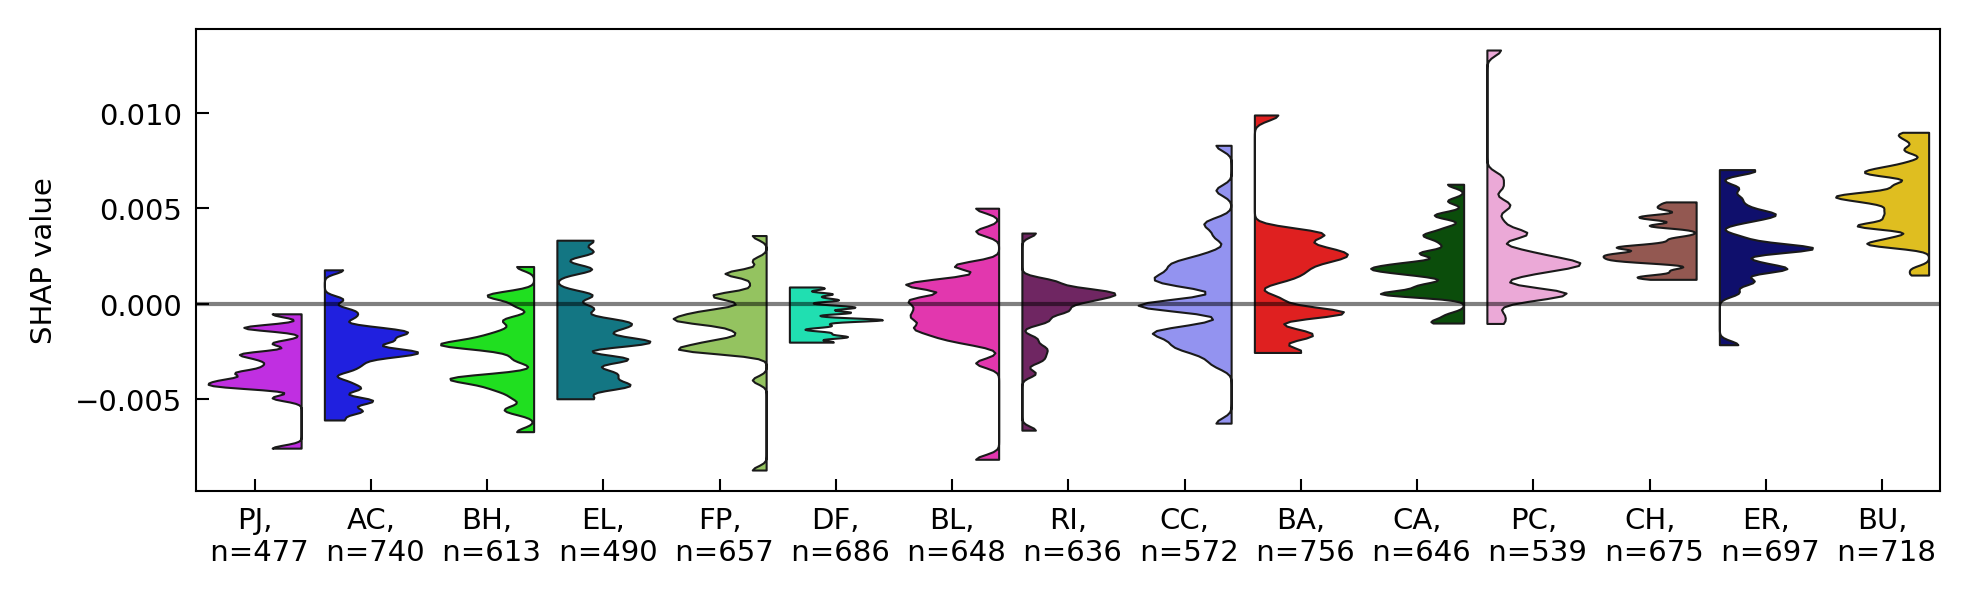

In [23]:
# Create the full violin plot, but we’ll mask the left half
plt.figure(figsize=(7.5, 2))
sns.violinplot(
    data=df_melted, x='Group', y='Values',
    bw_method=0.1,  # Minimal KDE smoothing to resemble a histogram
    density_norm='count',  # Width based on counts (histogram style)
    cut=0,  # Prevent extending past the data range
    inner=None,  # No inner KDE or boxplot lines
    palette=colors, 
    linewidth=.5,
    split=True,
)

# Adjust layout and show the plot
# plt.tight_layout()
# plt.grid(alpha=.2)
plt.axhline(y=0, c='k', alpha=.5, linewidth=1)
plt.ylabel('SHAP value')
plt.xlabel(None)
plt.savefig('figures/motifs/species_instability_shap.svg', dpi=300)
plt.show()

In [26]:
shap_dict = {}
for variable in controls:
    
    # pull out cases where species was present
    df_variable = df_sensitivity.iloc[df_sensitivity[variable].values>0]
    
    # save SHAP values
    column_vals = df_variable[f'{variable}-->Instability'].values
    column_name = variable.split('abs')[0] + f",\n n={len(column_vals)}"
    shap_dict[column_name] = column_vals
    
# Calculate the median for each list and sort the dictionary
shap_dict = dict(
    sorted(shap_dict.items(), key=lambda item: np.nanmedian(item[1]), reverse=False)
)

# Find the maximum length of the lists
max_len = max(len(lst) for lst in shap_dict.values())

# Pad the lists with NaN values to match the maximum length
padded_data = {key: list(lst) + [None] * (max_len - len(lst)) for key, lst in shap_dict.items()}

# Create the DataFrame
padded_shap_df = pd.DataFrame(padded_data)

# Melt the DataFrame to transform it into a long format
df_melted = pd.melt(padded_shap_df, var_name='Group', value_name='Values')

# set colors of each species
fbColorDict = {'Inulin':'#C9A188',
  'Starch':'#E5E5B0',
  'Xylan':'#F3F3D8',
  'Pectin':'#D8C69D',
  'AcGum':'#904F4F',
  'ArGal':'#B96F6F'};
colors = [fbColorDict[v.split(',')[0]] for v in padded_shap_df.columns.values]

/tmp/ipykernel_826574/3404814375.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


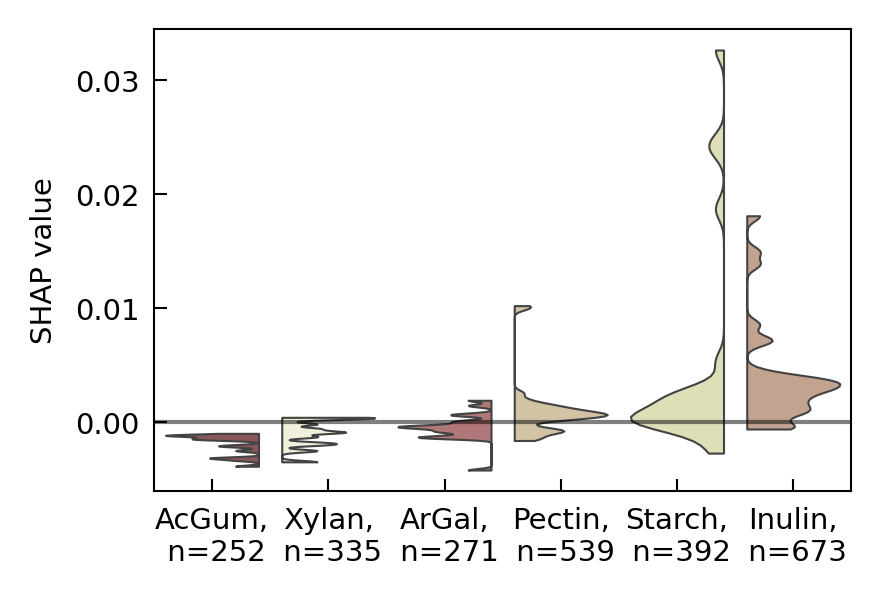

In [27]:
# Create the full violin plot, but we’ll mask the left half
plt.figure(figsize=(3., 2))
sns.violinplot(
    data=df_melted, x='Group', y='Values',
    bw_method=0.1,  # Minimal KDE smoothing to resemble a histogram
    density_norm='count',  # Width based on counts (histogram style)
    cut=0,  # Prevent extending past the data range
    inner=None,  # No inner KDE or boxplot lines
    linewidth=.5,
    palette=colors[:len(controls)],
    split='True'
)

# Adjust layout and show the plot
# plt.tight_layout()
# plt.grid(alpha=.2)
plt.axhline(y=0, c='k', alpha=.5, linewidth=1)
plt.ylabel('SHAP value')
plt.xlabel(None)
plt.savefig('figures/motifs/fiber_instability_shap.svg', dpi=300)
plt.show()
